<a href="https://colab.research.google.com/github/Takurreddy/DataMining_PredictiveAnalytics-MedicalDiagnosis/blob/main/DataMining_ProjectCodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder

# Load dataset
data = pd.read_csv("dps_dataset.csv")

# Preprocess 'symptoms' column
vectorizer_symptoms = CountVectorizer(tokenizer=lambda x: x.split(', '))
symptoms_encoded = vectorizer_symptoms.fit_transform(data['symptoms']).toarray()
symptoms_df = pd.DataFrame(symptoms_encoded, columns=vectorizer_symptoms.get_feature_names_out())

# Preprocess 'cures' column
vectorizer_cures = CountVectorizer(tokenizer=lambda x: x.split(', '))
cures_encoded = vectorizer_cures.fit_transform(data['cures']).toarray()
cures_df = pd.DataFrame(cures_encoded, columns=vectorizer_cures.get_feature_names_out())

# Identify categorical columns that need one-hot encoding (besides symptoms and cures)
categorical_cols = ['doctor', 'risk level'] # Assuming these are the remaining categorical columns

# One-hot encode these categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
categorical_encoded = encoder.fit_transform(data[categorical_cols])
categorical_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical, 'disease', 'symptoms', and 'cures' columns and concatenate with encoded features
X = pd.concat([data.drop(['disease', 'symptoms', 'cures'] + categorical_cols, axis=1), symptoms_df, cures_df, categorical_df], axis=1)
y = data["disease"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))

Naive Bayes Accuracy: 0.05


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Investigate Class Imbalance

Let's check the distribution of the target variable `disease` to identify any class imbalance issues. This can often lead to poor model performance, especially with metrics like accuracy.

Disease distribution:
 disease
pneumonia                   3
alzheimer's disease         3
stroke                      2
bronchitis                  2
cancer                      2
                           ..
epilepsy                    1
fibromyalgia                1
graves' disease             1
hashimoto's thyroiditis     1
lupus                       1
Name: count, Length: 88, dtype: int64


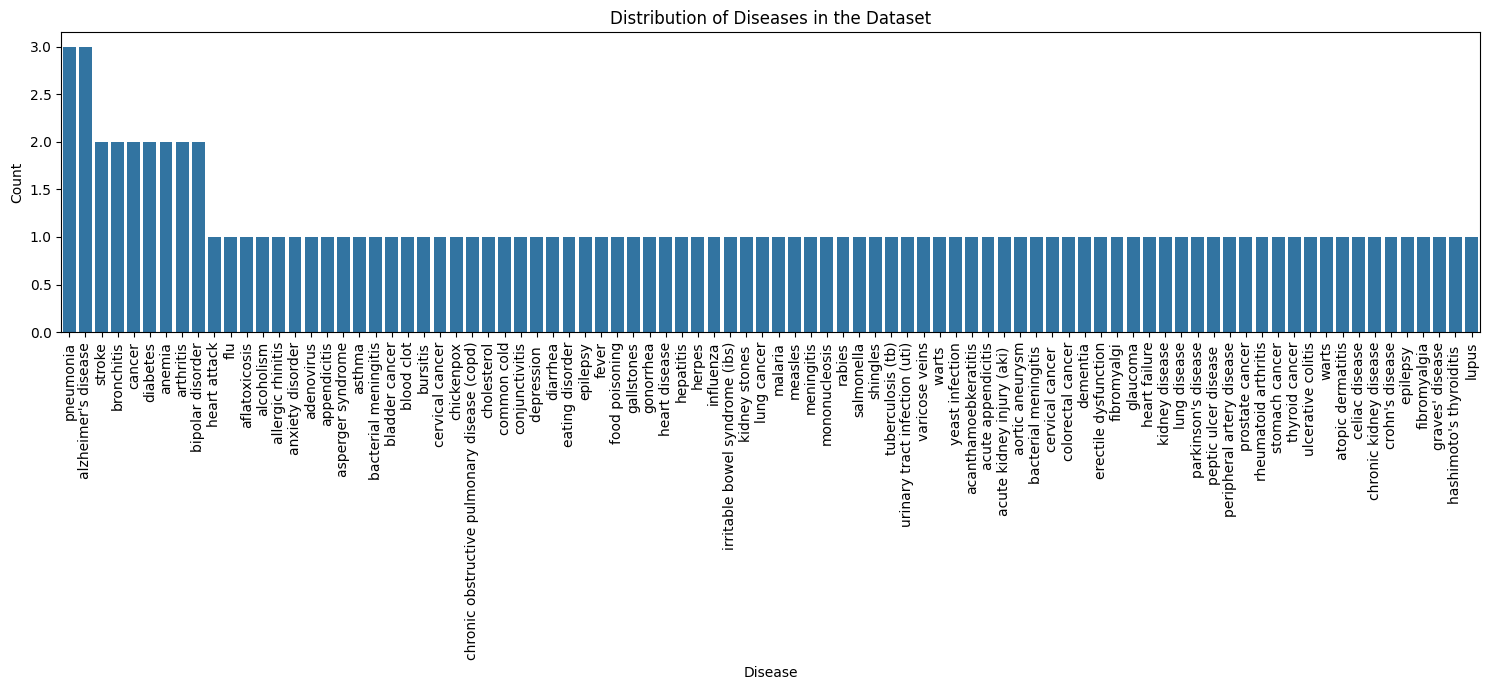

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the target variable
disease_counts = y.value_counts()

# Print the counts
print("Disease distribution:\n", disease_counts)

# Visualize the distribution
plt.figure(figsize=(15, 7))
sns.barplot(x=disease_counts.index, y=disease_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Diseases in the Dataset')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
#J48
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Model
model = DecisionTreeClassifier(criterion="entropy")  # J48 uses entropy
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Decision Tree (J48) Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree (J48) Accuracy: 0.0


In [6]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.05


In [7]:
#SVM(SMO)
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 0.05


In [8]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))

KNN Accuracy: 0.05
